In [16]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf

print('NumPy:', np.__version__)
print('TensorFlow:', tf.__version__)

NumPy: 2.0.2
TensorFlow: 2.19.0


In [17]:
# Colab setup: mount Google Drive and set dataset path
import os

try:
    from google.colab import drive  # Works only in Google Colab
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/Fertility_Diagnosis.txt'
except Exception:
    # Fallback for local/VS Code execution
    DATA_PATH = 'Fertility_Diagnosis.txt'

print('Using dataset path:', DATA_PATH)
print('File exists:', os.path.exists(DATA_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using dataset path: /content/drive/MyDrive/Fertility_Diagnosis.txt
File exists: True


In [18]:
# Step 2: Load dataset and create training/testing splits
# Data has 10 columns: first 9 features, last 1 target
raw_data = np.genfromtxt(DATA_PATH, delimiter=',')

X = raw_data[:, :9]
y = raw_data[:, 9].reshape(-1, 1)

# Reproducible random split (80% train, 20% test)
np.random.seed(42)
indices = np.random.permutation(len(X))
split_index = int(0.8 * len(X))
train_idx = indices[:split_index]
test_idx = indices[split_index:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('Dataset path:', DATA_PATH)
print('Dataset shape:', raw_data.shape)
print('X shape:', X.shape, 'y shape:', y.shape)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Dataset path: /content/drive/MyDrive/Fertility_Diagnosis.txt
Dataset shape: (100, 10)
X shape: (100, 9) y shape: (100, 1)
Train shape: (80, 9) (80, 1)
Test shape: (20, 9) (20, 1)


In [19]:
# Step 3: Define input/output layer sizes and error containers
input_layer_size = X_train.shape[1]
output_layer_size = 1

training_errors = []
testing_errors = []

error_tolerance = 0.05
alpha = 0.001
max_iters = 1_000_000
debug_every = 100_000

print('Input layer size:', input_layer_size)
print('Output layer size:', output_layer_size)
print('Error tolerance:', error_tolerance)
print('Learning rate (alpha):', alpha)

Input layer size: 9
Output layer size: 1
Error tolerance: 0.05
Learning rate (alpha): 0.001


In [20]:
# Helper functions

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def sigmoid_derivative(sigmoid_output):
    # derivative in terms of sigmoid output: s * (1 - s)
    return sigmoid_output * (1.0 - sigmoid_output)

In [21]:
# Steps 4 to 8: Train networks for hidden neurons from 1 to 9
for hidden_neurons in range(1, 10):
    # Step 4: Initialize random synapse weights
    np.random.seed(100 + hidden_neurons)
    w0 = 2 * np.random.random((input_layer_size, hidden_neurons)) - 1
    w1 = 2 * np.random.random((hidden_neurons, output_layer_size)) - 1

    # Initial feedforward and training MSE check
    l0 = X_train
    l1 = sigmoid(np.dot(l0, w0))
    l2 = sigmoid(np.dot(l1, w1))

    # Step 5 + Step 6: Backpropagation loop with convergence check
    stop_iter = max_iters
    for i in range(1, max_iters + 1):
        # Feedforward
        l0 = X_train
        l1 = sigmoid(np.dot(l0, w0))
        l2 = sigmoid(np.dot(l1, w1))

        # Cost (difference between true and predicted outputs)
        l2_error = y_train - l2
        mse = np.mean(np.square(l2_error))

        if mse < error_tolerance:
            stop_iter = i
            break

        # Backprop output layer
        l2_delta = l2_error * sigmoid_derivative(l2)

        # Backprop hidden layer
        l1_error = np.dot(l2_delta, w1.T)
        l1_delta = l1_error * sigmoid_derivative(l1)

        # Weight updates
        w1 += alpha * np.dot(l1.T, l2_delta)
        w0 += alpha * np.dot(l0.T, l1_delta)

    # Step 7: Evaluate training results
    train_l1 = sigmoid(np.dot(X_train, w0))
    train_l2 = sigmoid(np.dot(train_l1, w1))
    train_mse = mean_squared_error(y_train, train_l2)
    training_errors.append(train_mse)

    # Step 8: Evaluate testing results
    test_l1 = sigmoid(np.dot(X_test, w0))
    test_l2 = sigmoid(np.dot(test_l1, w1))
    test_mse = mean_squared_error(y_test, test_l2)
    testing_errors.append(test_mse)

    # Low-effort print output
    print('H:', hidden_neurons, 'iter:', stop_iter, 'train:', round(train_mse, 4), 'test:', round(test_mse, 4))

H: 1 iter: 1000000 train: 0.0633 test: 0.2094
H: 2 iter: 1000000 train: 0.0688 test: 0.2021
H: 3 iter: 155163 train: 0.05 test: 0.2756
H: 4 iter: 89604 train: 0.05 test: 0.262
H: 5 iter: 105625 train: 0.05 test: 0.2312
H: 6 iter: 100024 train: 0.05 test: 0.2527
H: 7 iter: 72367 train: 0.05 test: 0.2572
H: 8 iter: 72651 train: 0.05 test: 0.1938
H: 9 iter: 77267 train: 0.05 test: 0.2481


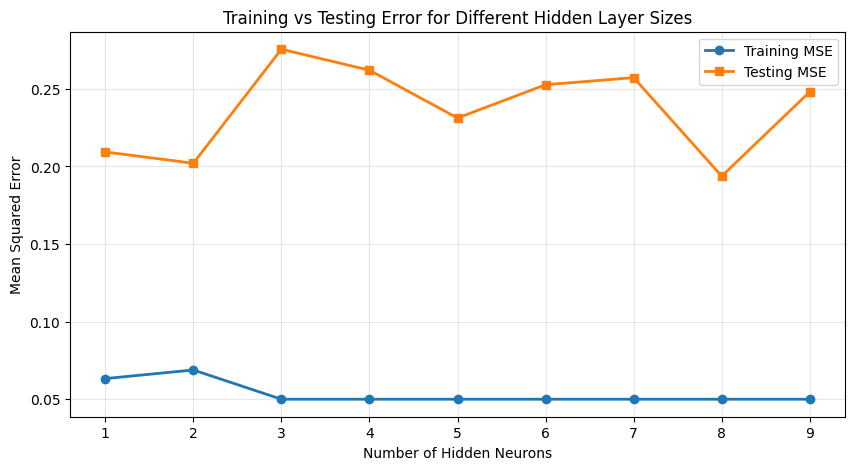

Training errors: [0.06329696763106546, 0.06884993452973473, 0.04999988871855403, 0.049999881393913745, 0.049999825901350804, 0.04999951404827328, 0.04999995878356882, 0.04999946080180886, 0.04999951083596287]
Testing errors: [0.20937556245254788, 0.2020528774226876, 0.2755596203989552, 0.2620355210167999, 0.2312078842405751, 0.25269025778809573, 0.2572388460521752, 0.19376197025433234, 0.24813050463454095]


In [23]:
# Step 9: Plot training and testing errors
hidden_range = list(range(1, 10))

plt.figure(figsize=(10, 5))
plt.plot(hidden_range, training_errors, marker='o', linewidth=2, label='Training MSE')
plt.plot(hidden_range, testing_errors, marker='s', linewidth=2, label='Testing MSE')
plt.xticks(hidden_range)
plt.xlabel('Number of Hidden Neurons')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Testing Error for Different Hidden Layer Sizes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('Training errors:', training_errors)
print('Testing errors:', testing_errors)

## Report Answers

1. **What happens if all the weights are initialized to zero (zero initialization)?**  
   All neurons in the same layer learn identical features because they receive identical gradients (symmetry problem), so the network fails to learn diverse representations and performs poorly.

2. **What is the difference between epoch, batch, and iteration in neural networks?**  
   - **Epoch:** One full pass over the entire training dataset.  
   - **Batch:** A subset of the training data used in one gradient update.  
   - **Iteration:** One parameter update step (usually one batch processed once).

3. **What is the key difference between stochastic gradient descent and batch gradient descent?**  
   - **Batch GD:** Uses all training samples for each update (stable but slower per update).  
   - **SGD:** Uses one sample per update (faster, noisier, can escape shallow minima more easily).

4. **What problems does a completely random initialization of a neural network lead to?**  
   If random values are too large/small, activations can saturate (especially sigmoid), causing vanishing or exploding gradients, unstable training, and slow or failed convergence.

5. **Name any ten hyperparameters in a multi-layer neural network.**  
   1. Learning rate  
   2. Number of hidden layers  
   3. Number of neurons per layer  
   4. Activation function  
   5. Batch size  
   6. Number of epochs  
   7. Weight initialization method  
   8. Optimizer type (SGD, Adam, etc.)  
   9. Dropout rate  
   10. L2 regularization coefficient